# Jupyter Notebook Version of my Hockey Analytics project

In [12]:
import numpy as np
import pandas as pd
from pathlib import Path
import sys

import matplotlib.pyplot as plt
from matplotlib.backends.backend_tkagg import FigureCanvasTkAgg
from matplotlib.figure import Figure
import seaborn as sns

from tabulate import tabulate
from prettytable import PrettyTable, TableStyle

from nhlpy.nhl_client import NHLClient

from nhlpy.api.query.builder import QueryBuilder, QueryContext
from nhlpy.api.query.filters.draft import DraftQuery
from nhlpy.api.query.filters.season import SeasonQuery
from nhlpy.api.query.filters.game_type import GameTypeQuery
from nhlpy.api.query.filters.position import PositionQuery, PositionTypes
from nhlpy.api.query.filters.franchise import FranchiseQuery
from nhlpy.api.query.filters.shoot_catch import ShootCatchesQuery
from nhlpy.api.query.filters.status import StatusQuery
from nhlpy.api.query.filters.opponent import OpponentQuery
from nhlpy.api.query.filters.home_road import HomeRoadQuery
from nhlpy.api.query.filters.experience import ExperienceQuery
from nhlpy.api.query.filters.decision import DecisionQuery

# custom functions from this repo
from utils.function_library import find_player_id
from utils.function_library import toi_string_to_float
from utils.function_library import load_summary_statistics_for_skaters
from utils.function_library import load_realtime_statistics_for_skaters
from utils.function_library import load_faceoffwins_statistics_for_skaters
from utils.function_library import skater_single_season_fantasy_points
from utils.function_library import get_stats_by_season
from utils.function_library import plot_stat_per_game
from utils.function_library import home_away_split

from matplotlib import rc
plt.rcParams.update({'font.size':22})

In [2]:
# grab directory where this is being run (needed for future cells)
notebook_dir = Path.cwd()
nhl_team_logo_path = str(notebook_dir)+"/nhl_team_logos/"

# Define your fantasy league scoring system here

### Example scoring system provided
- Note: variables must be defined as floats
- Note: categories not listed here cannot be used


In [3]:
fp_goals = 6.0
fp_assists = 4.0
fp_plusminus = 1.5
fp_pp_goals = 2.0
fp_pp_asists = 2.0
fp_sh_goals = 4.0
fp_sh_assists = 1.0
fp_game_winning_goals = 1.0
fp_shots = 0.75
fp_hits = 0.40
fp_blocks = 1.25
fp_fowins = 0.15
fp_folosses = -0.15
fp_pims = 0.0

# Define the player and season you want to calculate fantasy points for

### Both variables must be strings
- Example player: Macklin Celebrini
- Example season: 20252026

- Note: player name must be properly capitalized with space between first and last name
- Note: season must have beginning and end year with no space in between

### We also grab the player_id, which will be used later on to query for stats

In [4]:
skater_name = "Tyler Toffoli"
season = "20252026"
skater_id = find_player_id(skater_name, season)

### This cell prints the number of fantasy points for the defined player in the defined regular season using the defined scoring system. The number of fantasy points are broken down by stat, so you can visualize how the player typically scores their points.

In [5]:
tot_fp = skater_single_season_fantasy_points(skater_name,
    season,
    fp_goals,
    fp_assists,
    fp_plusminus,
    fp_pp_goals,
    fp_pp_asists,
    fp_sh_goals,
    fp_sh_assists,
    fp_game_winning_goals,
    fp_shots,
    fp_hits,
    fp_blocks,
    fp_fowins,
    fp_folosses,
    fp_pims,
    )

Tyler Toffoli fantasy points = 433.45
 
# of games played = 79
Fantasy points per game = 5.486708860759493
 
 
+----------------------------------------------------------------------------------------------------+
|                                  Fantasy Points Breakdown by Stat                                  |
+------------------------------+-------------+----------------+--------------+-----------------------+
|          Stat Name           | Total Stats | Fantasy Points | Stats / Game | Fantasy Points / Game |
+------------------------------+-------------+----------------+--------------+-----------------------+
|            Goals             |      19     |     114.0      |     0.24     |          1.44         |
|           Assists            |      30     |     120.0      |     0.38     |          1.52         |
|          Plus/Minus          |     -12     |     -18.0      |    -0.15     |         -0.23         |
|      Bonus for PP Goals      |      6      |      12.0      |  

### The following table shows the above stats broken into home vs away splits, since some players perform better at home than on the road (and vice versa)

### To better compare players, the stats are also normalized to both:
- a per game basis (since games missed due to injury exists)
- a per 60 minutes basis (since average time on ice varies from player to player)

In [6]:
home_away_split(skater_id, season)

+-----------------------------------------------------------------------+
|                        Home vs. Road Stat Split                       |
+---------------------------------+-----------+------------+------------+
|               Stat              | All Games | Home Games | Away Games |
+---------------------------------+-----------+------------+------------+
|            # of games           |     79    |     40     |     39     |
|      Average TOI [minutes]      |   14.97   |   14.88    |   15.07    |
|       Average # of Shifts       |   18.38   |   17.92    |   18.85    |
+---------------------------------+-----------+------------+------------+
|           Total Points          |     49    |     26     |     23     |
|      Total Points per Game      |    0.62   |    0.65    |    0.59    |
|   Total Points per 60 minutes   |    2.49   |    2.62    |    2.35    |
+---------------------------------+-----------+------------+------------+
|           Total Goals           |   

# Next we visualize the player's career stats
### This plots the player's stats for each season. The career average with standard deviation is also shown to identify outlier seasons.
- Total stats per season are shown. Also shown are the stats/game normalized based on the number of games played in that season.

### This cell queries the player's career stats

In [7]:
df_skater_career_stats = get_stats_by_season(skater_id, nhl_team_logo_path)

### Plot the global stats
- Games played
- Average time on ice
- Total goals, assists, points, and shots
- Goals, assists, points, and shots per game
- Shooting %
- Face-off winning %

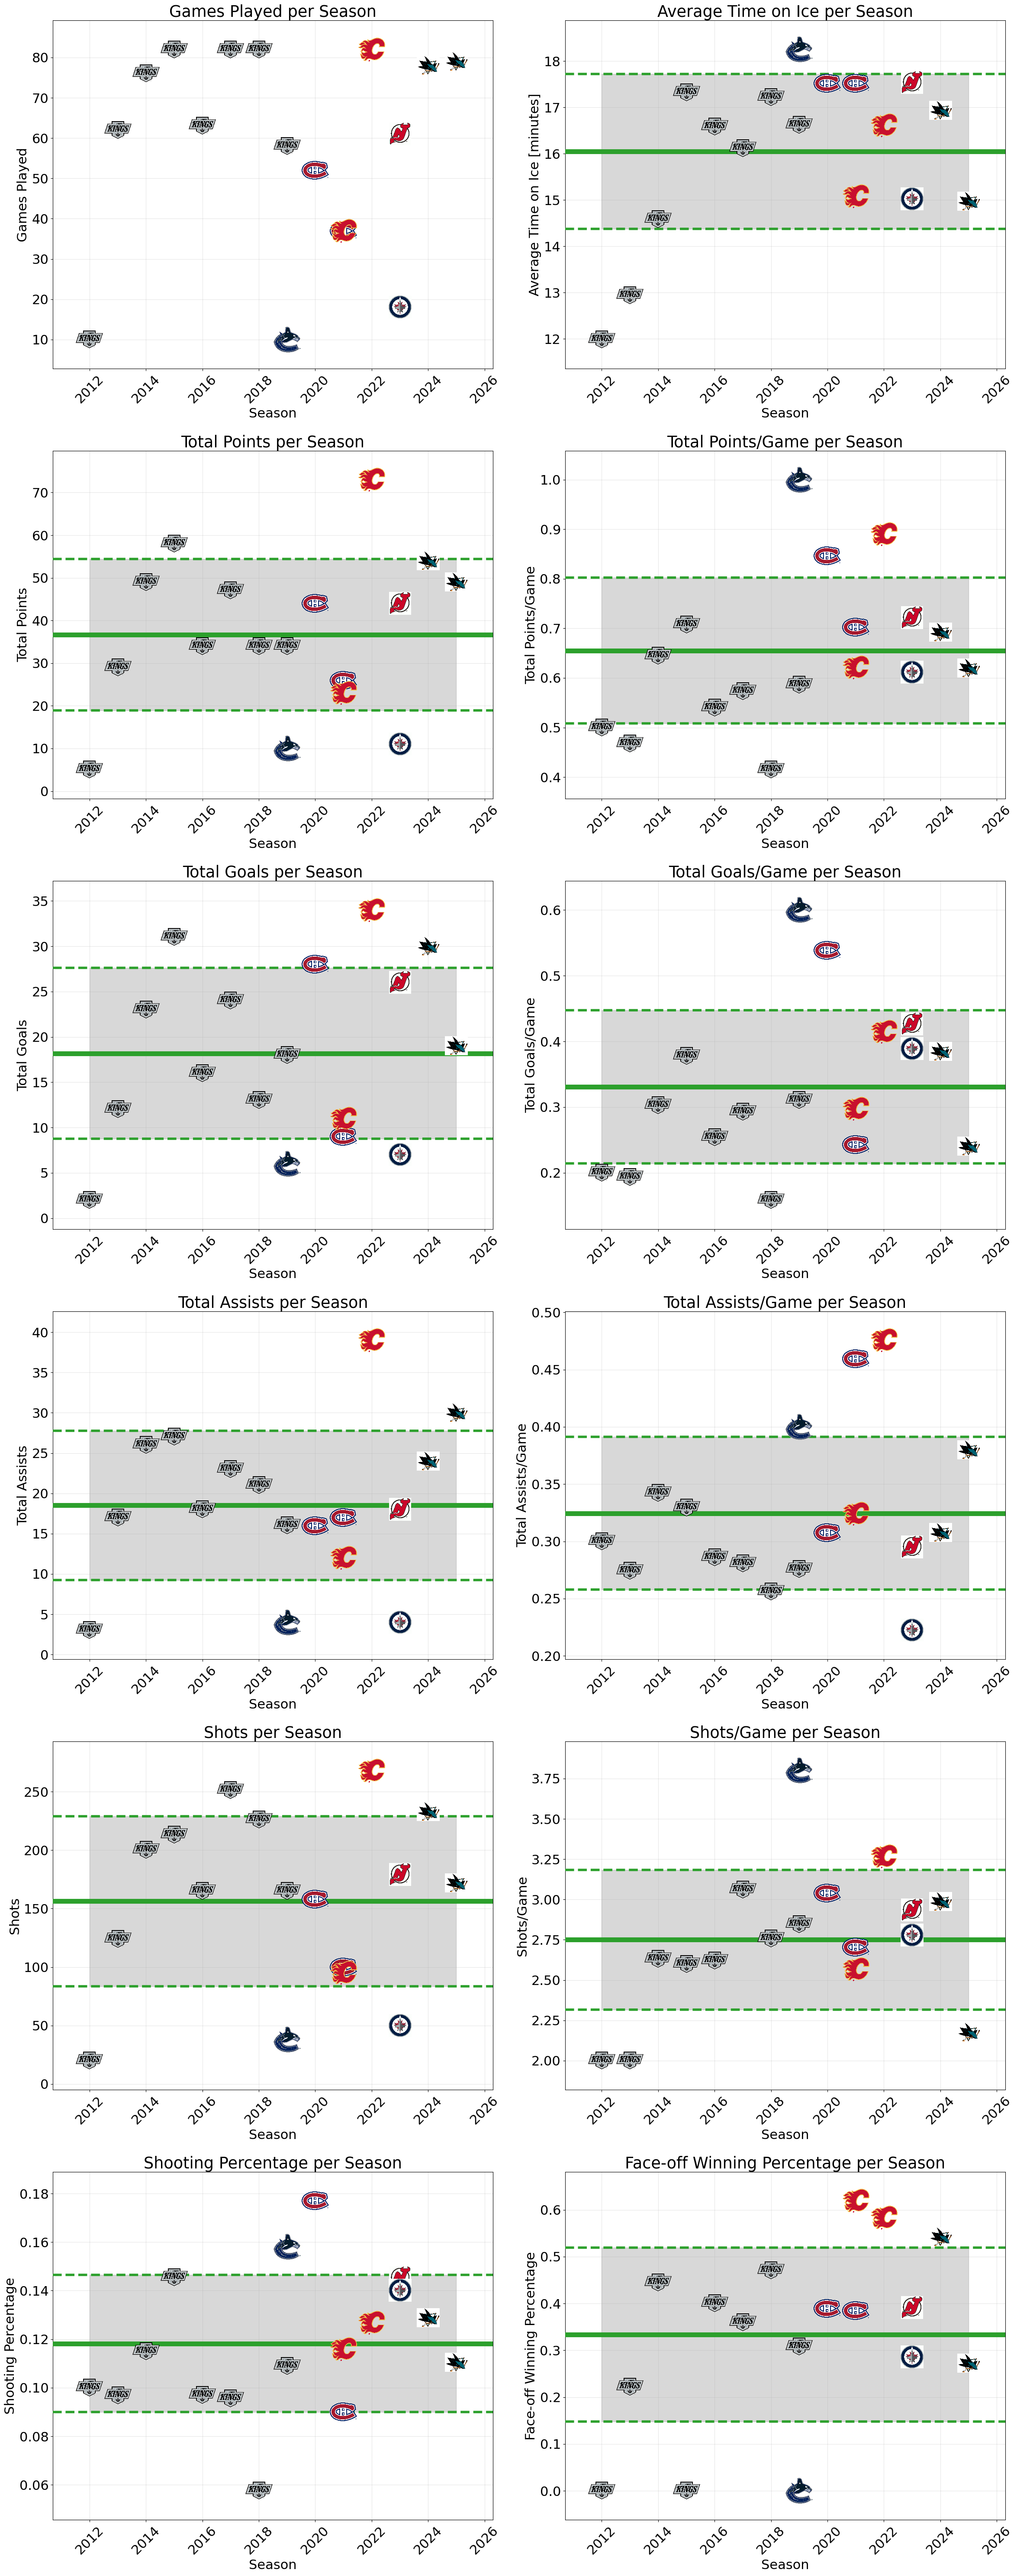

In [8]:
fig, ((ax1, ax2), (ax3, ax4), (ax5, ax6), 
      (ax7, ax8), (ax9, ax10), (ax11, ax12),) = plt.subplots(nrows=6, ncols=2, figsize=(24, 60))

plot_stat_per_game(ax1, "ax1", df_skater_career_stats, False, "gamesPlayed", "Games Played per Season", "Games Played")
plot_stat_per_game(ax2, "ax2", df_skater_career_stats, True, "avgToi_float", "Average Time on Ice per Season", "Average Time on Ice [minutes]")
plot_stat_per_game(ax3, "ax3", df_skater_career_stats, True, "points", "Total Points per Season", "Total Points")
plot_stat_per_game(ax4, "ax4", df_skater_career_stats, True, "points_per_game", "Total Points/Game per Season", "Total Points/Game")
plot_stat_per_game(ax5, "ax5", df_skater_career_stats, True, "goals", "Total Goals per Season", "Total Goals")
plot_stat_per_game(ax6, "ax6", df_skater_career_stats, True, "goals_per_game", "Total Goals/Game per Season", "Total Goals/Game")
plot_stat_per_game(ax7, "ax7", df_skater_career_stats, True, "assists", "Total Assists per Season", "Total Assists")
plot_stat_per_game(ax8, "ax8", df_skater_career_stats, True, "assists_per_game", "Total Assists/Game per Season", "Total Assists/Game")
plot_stat_per_game(ax9, "ax9", df_skater_career_stats, True, "shots", "Shots per Season", "Shots")
plot_stat_per_game(ax10, "ax10", df_skater_career_stats, True, "shots_per_game", "Shots/Game per Season", "Shots/Game")
plot_stat_per_game(ax11, "ax11", df_skater_career_stats, True, "shootingPctg", "Shooting Percentage per Season", "Shooting Percentage")
plot_stat_per_game(ax12, "ax12", df_skater_career_stats, True, "faceoffWinningPctg", "Face-off Winning Percentage per Season", "Face-off Winning Percentage")

fig.tight_layout()

### Even strength goals, assists and points

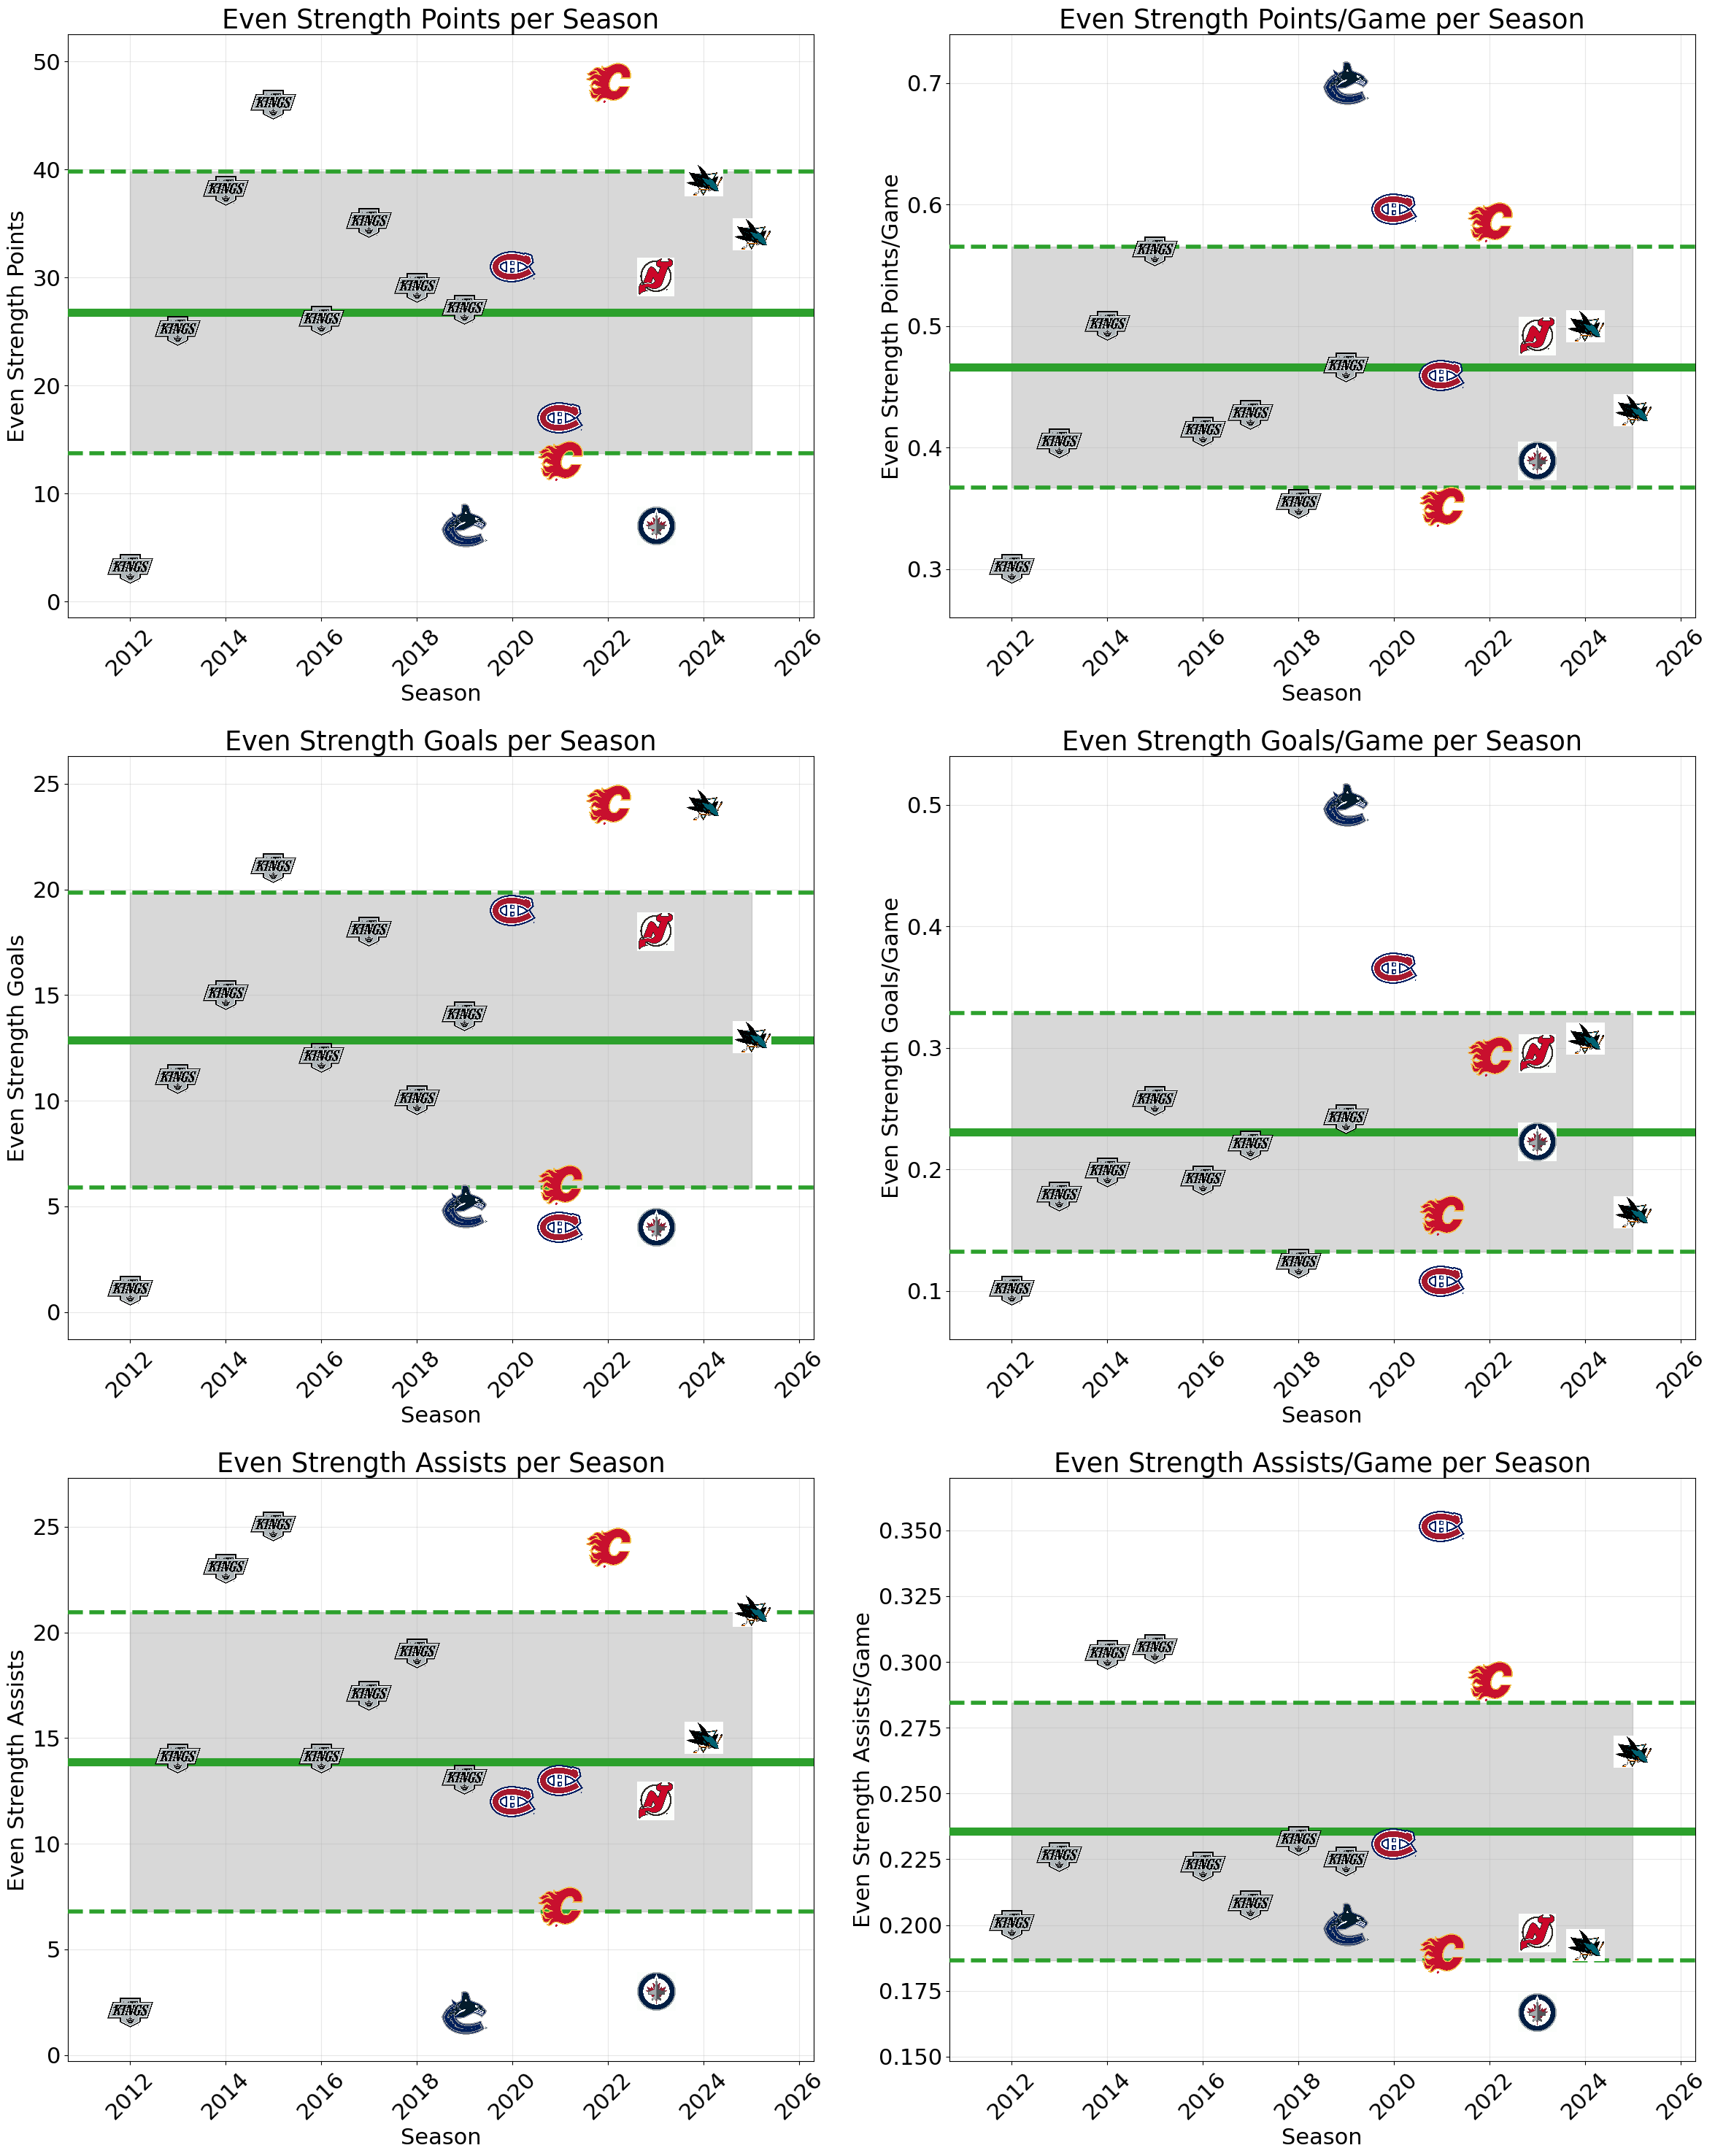

In [9]:
fig, ((ax1, ax2), (ax3, ax4), (ax5, ax6),) = plt.subplots(nrows=3, ncols=2, figsize=(24, 30))

plot_stat_per_game(ax1, "ax1", df_skater_career_stats, True, "even_strength_points", "Even Strength Points per Season", "Even Strength Points")
plot_stat_per_game(ax2, "ax2", df_skater_career_stats, True, "even_strength_points_per_game", "Even Strength Points/Game per Season", "Even Strength Points/Game")
plot_stat_per_game(ax3, "ax3", df_skater_career_stats, True, "even_strength_goals", "Even Strength Goals per Season", "Even Strength Goals")
plot_stat_per_game(ax4, "ax4", df_skater_career_stats, True, "even_strength_goals_per_game", "Even Strength Goals/Game per Season", "Even Strength Goals/Game")
plot_stat_per_game(ax5, "ax5", df_skater_career_stats, True, "even_strength_assists", "Even Strength Assists per Season", "Even Strength Assists")
plot_stat_per_game(ax6, "ax6", df_skater_career_stats, True, "even_strength_assists_per_game", "Even Strength Assists/Game per Season", "Even Strength Assists/Game")

fig.tight_layout()

### Power play goals, assists, and points

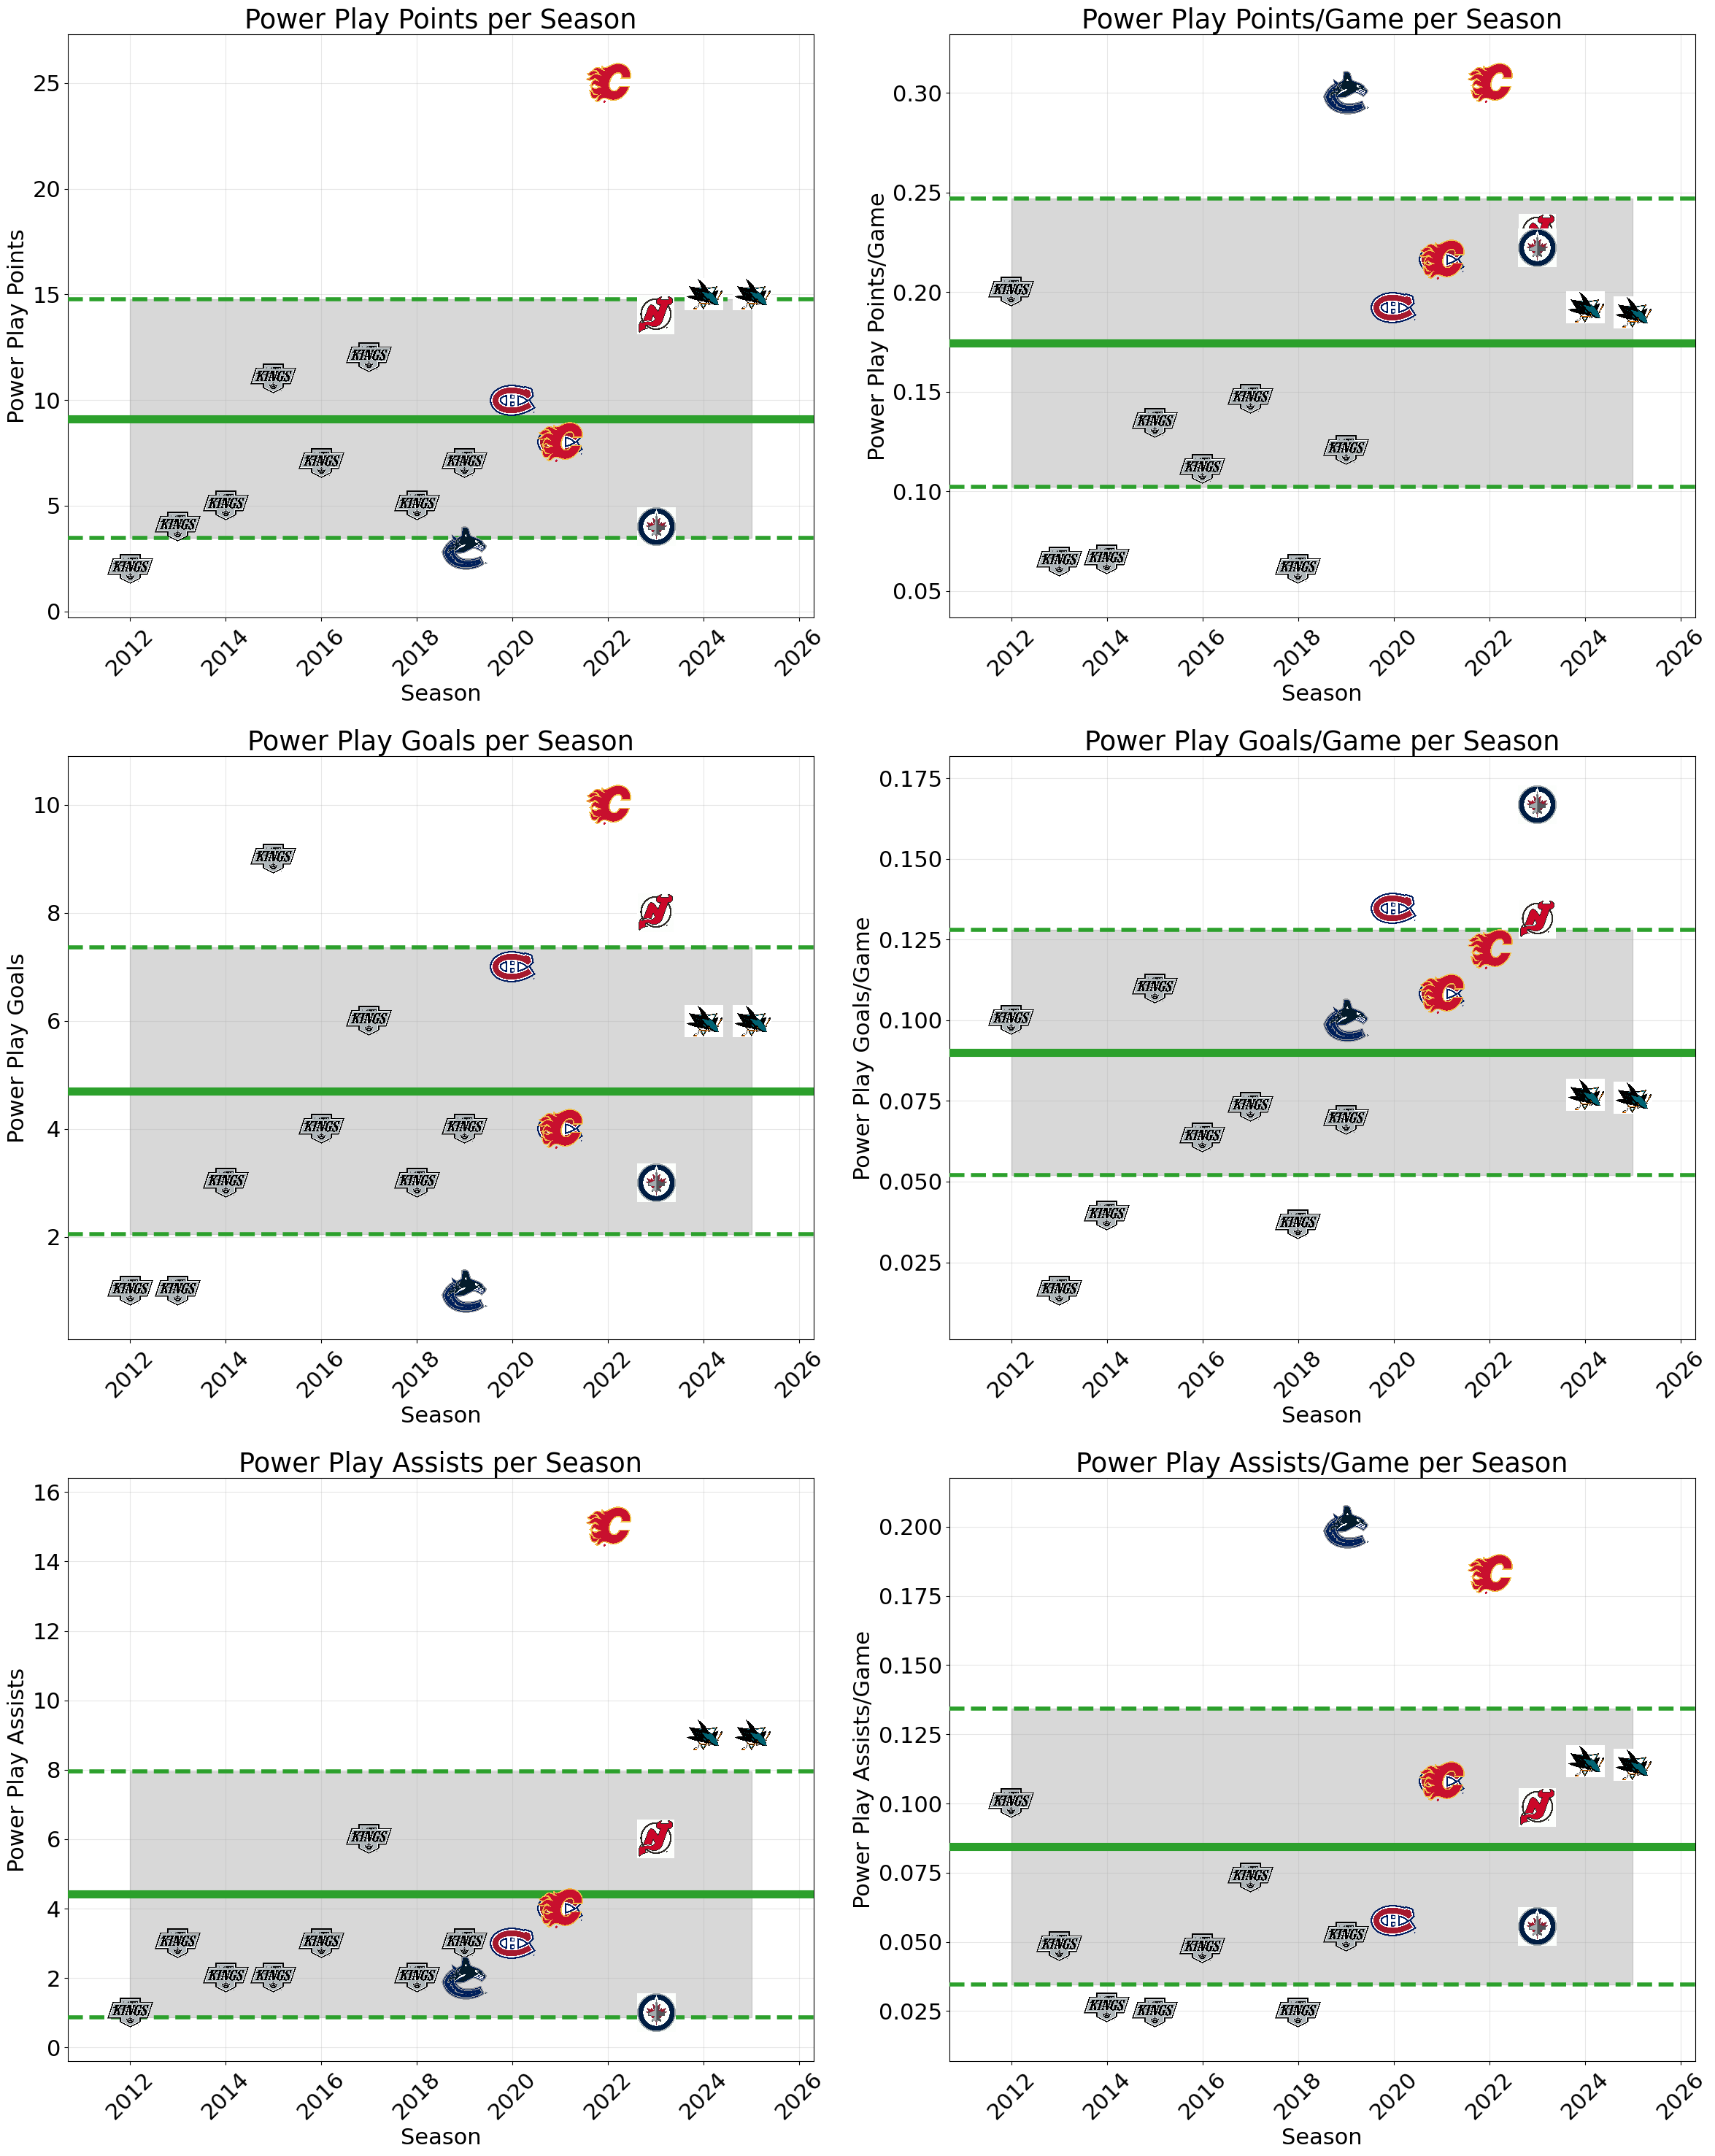

In [10]:
fig, ((ax1, ax2), (ax3, ax4), (ax5, ax6),) = plt.subplots(nrows=3, ncols=2, figsize=(24, 30))

plot_stat_per_game(ax1, "ax1", df_skater_career_stats, True, "powerPlayPoints", "Power Play Points per Season", "Power Play Points")
plot_stat_per_game(ax2, "ax2", df_skater_career_stats, True, "powerPlayPoints_per_game", "Power Play Points/Game per Season", "Power Play Points/Game")
plot_stat_per_game(ax3, "ax3", df_skater_career_stats, True, "powerPlayGoals", "Power Play Goals per Season", "Power Play Goals")
plot_stat_per_game(ax4, "ax4", df_skater_career_stats, True, "powerPlayGoals_per_game", "Power Play Goals/Game per Season", "Power Play Goals/Game")
plot_stat_per_game(ax5, "ax5", df_skater_career_stats, True, "powerPlayAssists", "Power Play Assists per Season", "Power Play Assists")
plot_stat_per_game(ax6, "ax6", df_skater_career_stats, True, "powerPlayAssists_per_game", "Power Play Assists/Game per Season", "Power Play Assists/Game")

fig.tight_layout()

### Short-handed goals, assists, and points

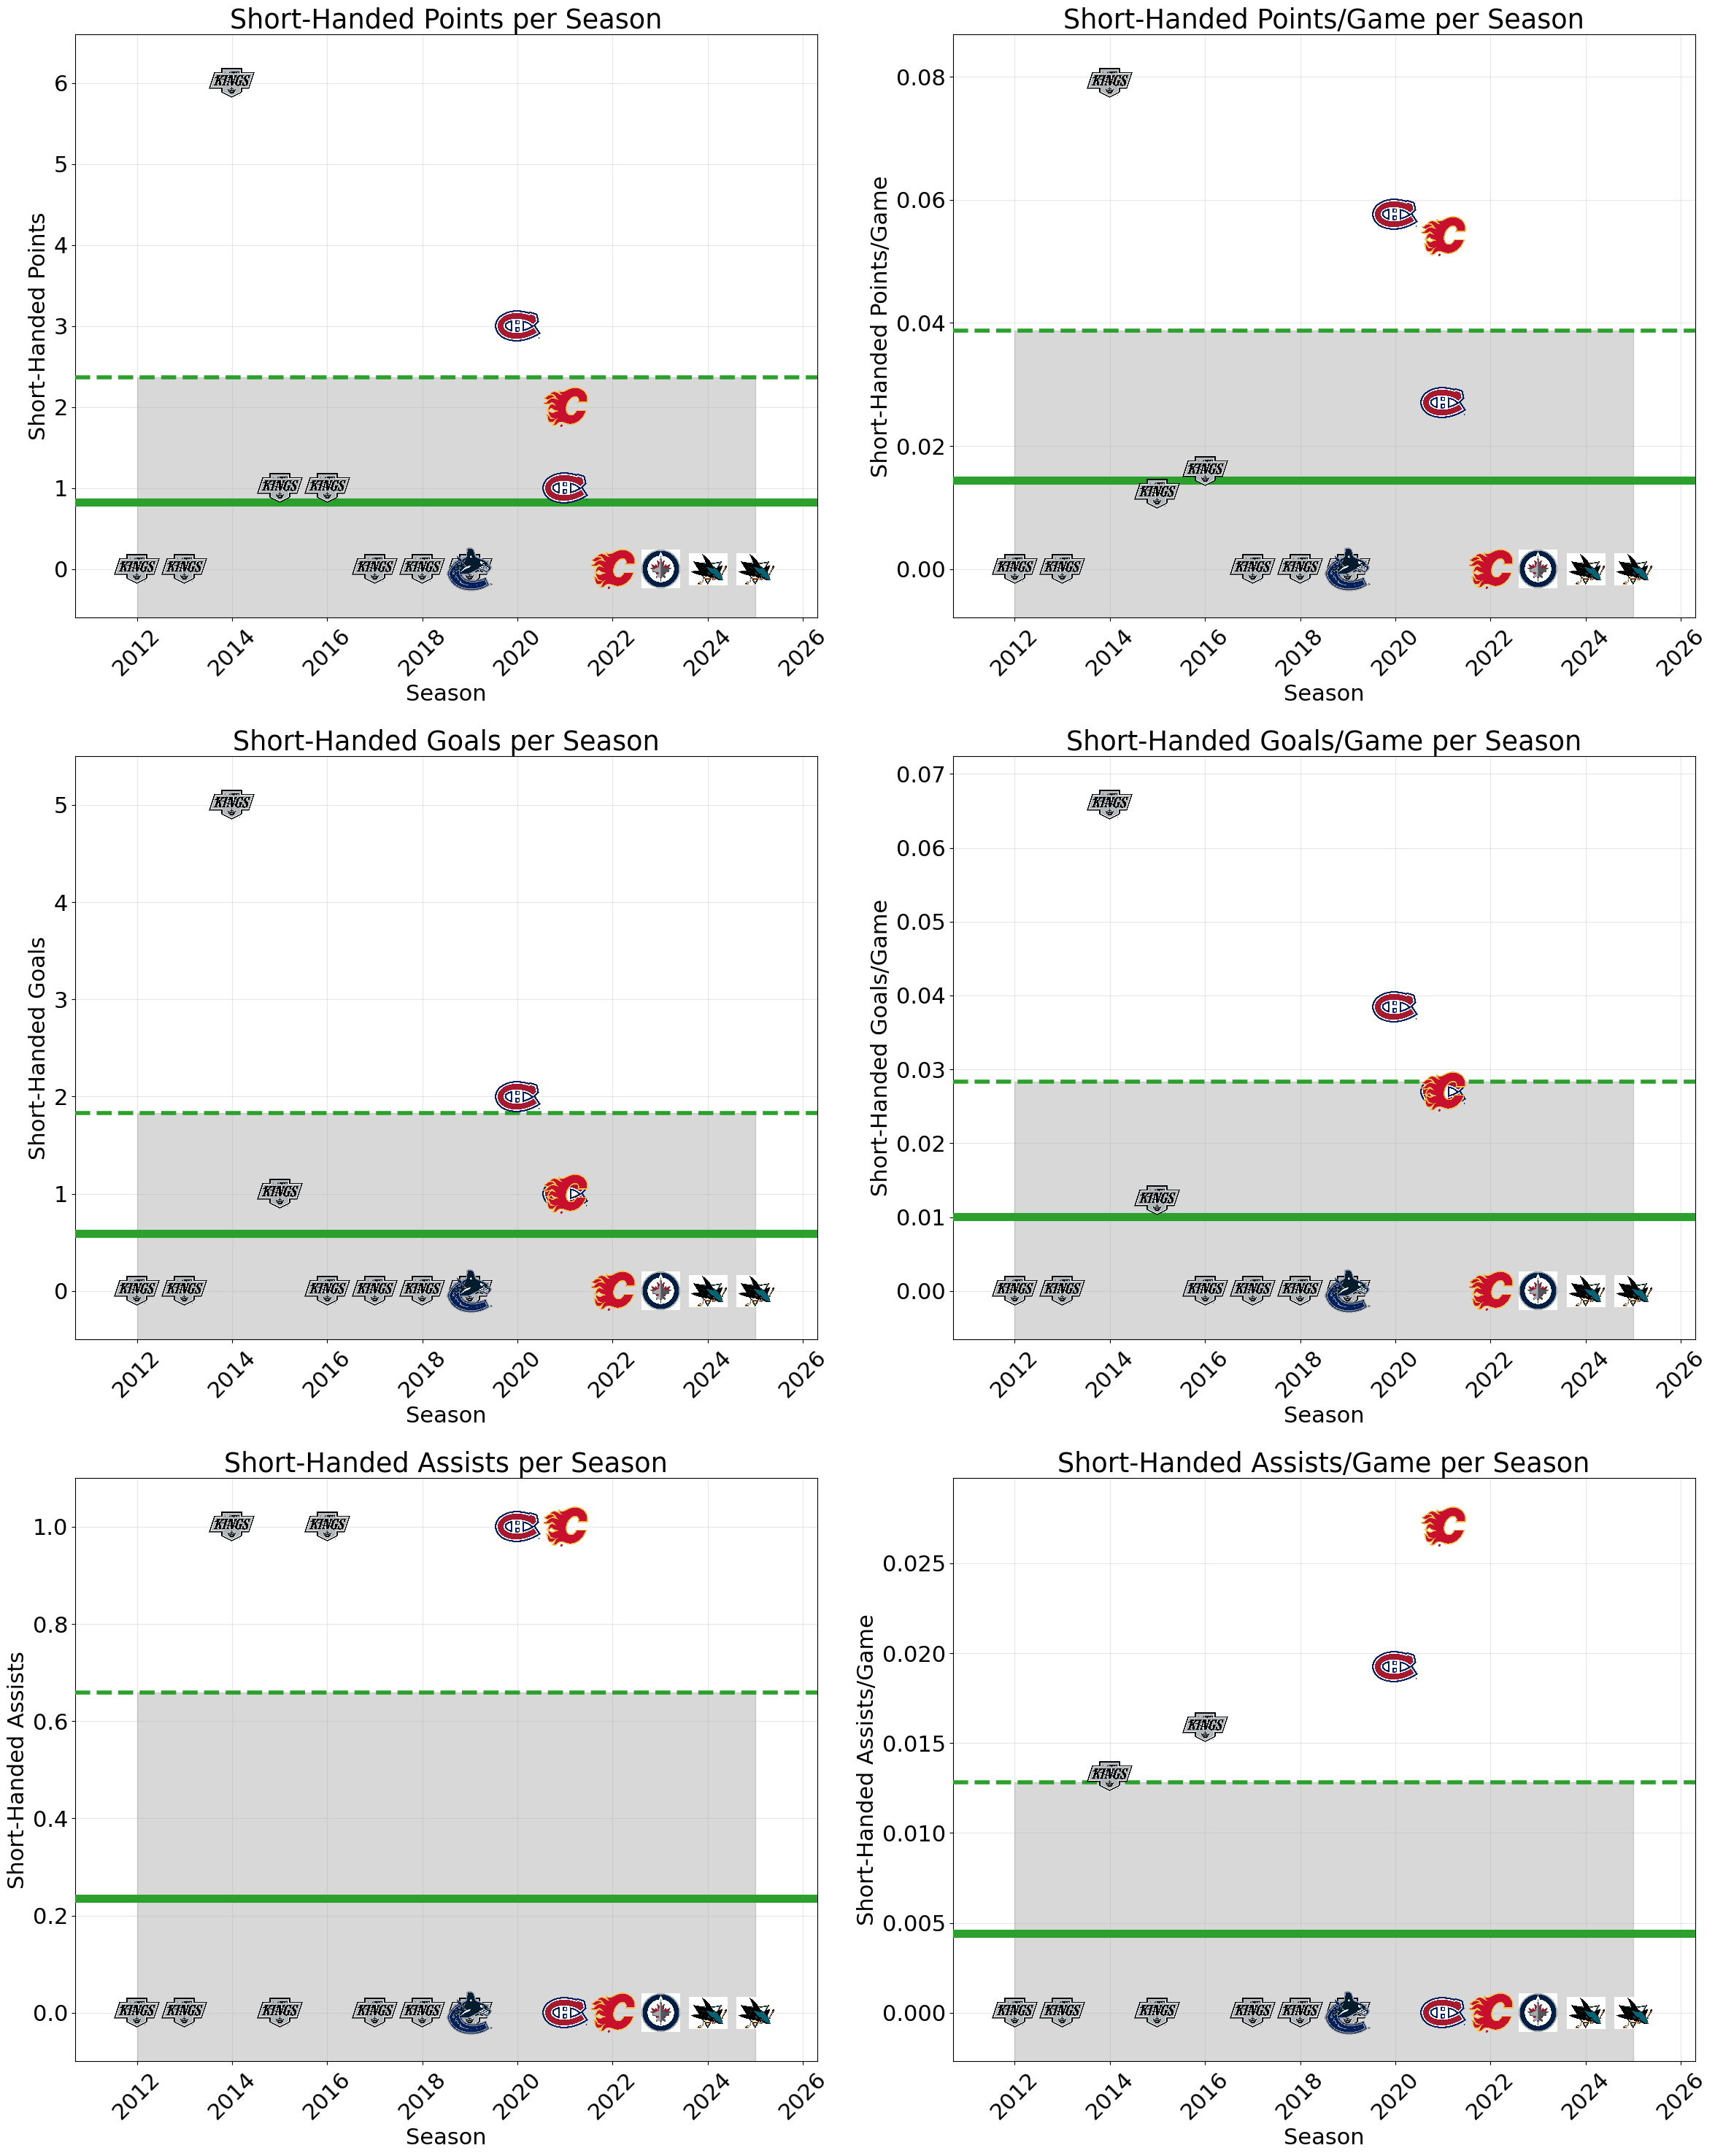

In [11]:
fig, ((ax1, ax2), (ax3, ax4), (ax5, ax6),) = plt.subplots(nrows=3, ncols=2, figsize=(24, 30))

plot_stat_per_game(ax1, "ax1", df_skater_career_stats, True, "shorthandedPoints", "Short-Handed Points per Season", "Short-Handed Points")
plot_stat_per_game(ax2, "ax2", df_skater_career_stats, True, "shorthandedPoints_per_game", "Short-Handed Points/Game per Season", "Short-Handed Points/Game")
plot_stat_per_game(ax3, "ax3", df_skater_career_stats, True, "shorthandedGoals", "Short-Handed Goals per Season", "Short-Handed Goals")
plot_stat_per_game(ax4, "ax4", df_skater_career_stats, True, "shorthandedGoals_per_game", "Short-Handed Goals/Game per Season", "Short-Handed Goals/Game")
plot_stat_per_game(ax5, "ax5", df_skater_career_stats, True, "shorthandedAssists", "Short-Handed Assists per Season", "Short-Handed Assists")
plot_stat_per_game(ax6, "ax6", df_skater_career_stats, True, "shorthandedAssists_per_game", "Short-Handed Assists/Game per Season", "Short-Handed Assists/Game")

fig.tight_layout()